# Exercise 3: Neural networks in PyTorch

In this exercise you’ll implement small neural-network building blocks from scratch and use them to train a simple classifier.

You’ll cover:
- **Basic layers**: Linear, Embedding, Dropout
- **Normalization**: LayerNorm and RMSNorm
- **MLPs + residual**: composing layers into deeper networks
- **Classification**: generating a learnable dataset, implementing cross-entropy from logits, and writing a minimal training loop

As before: fill in all `TODO`s without changing function names or signatures.
Use small sanity checks and compare to PyTorch reference implementations when useful.

In [91]:
from __future__ import annotations

import torch
from torch import nn

## Basic layers

In this section you’ll implement a few core layers that appear everywhere:

### `Linear`
A fully-connected layer that follows nn.Linear conventions:  
`y = x @ Wᵀ + b`

Important details:
- Parameters should be registered as `nn.Parameter`
- Store weight as (out_features, in_features) like nn.Linear.
- The forward pass should support leading batch dimensions: `x` can be shape `(..., in_features)`

### `Embedding`
An embedding table maps integer ids to vectors:
- input: token ids `idx` of shape `(...,)`
- output: vectors of shape `(..., embedding_dim)`

This is essentially a learnable lookup table.

### `Dropout`
Dropout randomly zeroes activations during training to reduce overfitting.
Implementation details:
- Only active in `model.train()` mode
- In training: drop with probability `p` and scale the kept values by `1/(1-p)` so the expected value stays the same
- In eval: return the input unchanged

## Instructions
- Do not use PyTorch reference modules for the parts you implement (e.g. don’t call nn.Linear inside your Linear).
- You may use standard tensor ops that you learned before (matmul, sum, mean, rsqrt, indexing, etc.).
- Use a parameter initialization method of your choice. We recommend something like Xavier-uniform.


In [92]:
def fan_in_fan_out(weight: torch.Tensor) -> tuple[int, int]:
    """Compute (fan_in, fan_out) for a weight tensor."""
    fan_in = weight.shape[1]
    fan_out = weight.shape[0]
    return fan_in, fan_out

def xavier_uniform_(weight: torch.Tensor, gain: float = 1.0) -> torch.Tensor:
    """
    In-place Xavier/Glorot uniform init:
      bound = gain * sqrt(6 / (fan_in + fan_out))
      U(-bound, bound)
    """
    fan_in, fan_out = fan_in_fan_out(weight)
    bound = gain * (6 / (fan_in + fan_out)) ** 0.5
    with torch.no_grad():
        return weight.uniform_(-bound, bound)
    
def kaiming_uniform_(weight: torch.Tensor, nonlinearity: str = "relu") -> torch.Tensor:
    """
    In-place Kaiming/He uniform init.

    Follow this common choice:
      gain = sqrt(2) for ReLU
      std = gain / sqrt(fan_in)
      bound = sqrt(3) * std
      U(-bound, bound)
    """
    if nonlinearity == "relu":
        gain = 2 ** 0.5
    else:
        raise ValueError(f"Unsupported nonlinearity: {nonlinearity}")
    fan_in, _ = fan_in_fan_out(weight)
    std = gain / (fan_in ** 0.5)
    bound = (3 ** 0.5) * std
    with torch.no_grad():
        return weight.uniform_(-bound, bound)
    
def init_linear_(layer: nn.Linear, scheme: str = "xavier") -> nn.Linear:
    """
    Initialize an nn.Linear in-place.

    scheme:
      - "xavier"
      - "kaiming_relu"
      - "zero" (weights and bias = 0)
    """
    if scheme == "xavier":
        xavier_uniform_(layer.weight)
        if layer.bias is not None:
            nn.init.zeros_(layer.bias)
    elif scheme == "kaiming_relu":
        kaiming_uniform_(layer.weight, nonlinearity="relu")
        if layer.bias is not None:
            nn.init.zeros_(layer.bias)
    elif scheme == "zero":
        nn.init.zeros_(layer.weight)
        if layer.bias is not None:
            nn.init.zeros_(layer.bias)
    else:
        raise ValueError(f"Unsupported initialization scheme: {scheme}")
    return layer

In [93]:
class Linear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        if bias:
            self.bias = nn.Parameter(torch.empty(out_features))
        else:
            self.register_parameter("bias", None)
        init_linear_(self, scheme="kaiming_relu")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., in_features)
        return: (..., out_features)
        """
        return x @ self.weight.T + (self.bias if self.bias is not None else 0)

In [94]:
class Embedding(nn.Module):
    def __init__(self, num_embeddings: int, embedding_dim: int):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.weight = nn.Parameter(torch.empty(num_embeddings, embedding_dim))
        self.bias = self.register_parameter("bias", None)
        init_linear_(self, scheme="xavier")

    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        """
        idx: (...,) int64
        return: (..., embedding_dim)
        """
        return self.weight[idx]

In [95]:
class Dropout(nn.Module):
    def __init__(self, p: float):
        super().__init__()
        self.p = p

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        In train mode: drop with prob p and scale by 1/(1-p).
        In eval mode: return x unchanged.
        """
        if self.training:
            mask = (torch.rand_like(x) > self.p).float()
            return x * mask / (1 - self.p)
        else:
            return x

## Normalization

Normalization layers help stabilize training by controlling activation statistics.

### LayerNorm
LayerNorm normalizes each example across its **feature dimension** (the last dimension):

- compute mean and variance over the last dimension
- normalize: `(x - mean) / sqrt(var + eps)`
- apply learnable per-feature scale and shift (`weight`, `bias`)

**In this exercise, assume `elementwise_affine=True` (always include `weight` and `bias`).**  
`weight` and `bias` each have shape `(D,)`.

LayerNorm is widely used in transformers because it does not depend on batch statistics.

### RMSNorm
RMSNorm is similar to LayerNorm but normalizes using only the root-mean-square:
- `x / sqrt(mean(x^2) + eps)` over the last dimension
- usually includes a learnable scale (`weight`)
- no mean subtraction

RMSNorm is popular in modern LLMs because it's faster.


In [96]:
class LayerNorm(nn.Module):
    def __init__(
        self, normalized_shape: int, eps: float = 1e-5, elementwise_affine: bool = True
    ):
        super().__init__()
        self.normalized_shape = normalized_shape
        self.eps = eps
        self.elementwise_affine = elementwise_affine
        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.bias = nn.Parameter(torch.zeros(normalized_shape))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Normalize over the last dimension.
        x: (..., D)
        """
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        x_normalized = (x - mean) / torch.sqrt(var + self.eps)
        weight = self.weight.view(1, -1)
        bias = self.bias.view(1, -1)
        return x_normalized * weight + bias

In [97]:
class RMSNorm(nn.Module):
    def __init__(self, normalized_shape: int, eps: float = 1e-8):
        super().__init__()
        self.normalized_shape = normalized_shape
        self.eps = eps
        self.weight = nn.Parameter(torch.empty(normalized_shape).view(1, -1))
        self.bias = self.register_parameter("bias", None)
        init_linear_(self, scheme="xavier")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        RMSNorm: x / sqrt(mean(x^2) + eps) * weight
        over the last dimension.
        """
        return x / torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps) * self.weight

## MLPs and residual networks

Now you’ll build larger networks by composing layers.

### MLP
An MLP is a stack of `depth` Linear layers with non-linear activations (use GELU) in between.
In this exercise you’ll support:
- configurable depth
- a hidden dimension
- optional LayerNorm between layers (a common stabilization trick)

A key skill is building networks using `nn.ModuleList` / `nn.Sequential` while keeping shapes consistent.

### Transformer-style FeedForward (FFN)
A transformer block contains a position-wise feedforward network:
- `D -> 4D -> D` (by default)
- activation is typically **GELU**

This is essentially an MLP applied independently at each token position.

### Residual wrapper
Residual connections are the simplest form of “skip connection”:
- output is `x + fn(x)`

They improve gradient flow and allow training deeper networks more reliably.

In [98]:
class MLP(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        depth: int,
        use_layernorm: bool = False,
    ):
        super().__init__()
        self.in_dim = in_dim
        self.hidden_dim = hidden_dim
        self.out_dim = out_dim
        self.depth = depth
        self.use_layernorm = use_layernorm

        self.layers = nn.ModuleList()
        for i in range(depth):
            layer_in = in_dim if i == 0 else hidden_dim
            layer_out = out_dim if i == depth - 1 else hidden_dim
            self.layers.append(Linear(layer_in, layer_out))
            if i < depth - 1:
                self.layers.append(nn.GELU())
                if use_layernorm:
                    self.layers.append(LayerNorm(layer_out))
        self.net = nn.Sequential(*self.layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [99]:
class FeedForward(nn.Module):
    """
    Transformer-style FFN: D -> 4D -> D (default)
    """

    def __init__(self, d_model: int, d_ff: int | None = None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.linear1 = Linear(d_model, d_ff)
        self.linear2 = Linear(d_ff, d_model)
        self.activation = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear2(self.activation(self.linear1(x)))

In [100]:
class Residual(nn.Module):
    def __init__(self, fn: nn.Module):
        super().__init__()
        self.fn = fn

    def forward(self, x: torch.Tensor, *args, **kwargs) -> torch.Tensor:
        return x + self.fn(x, *args, **kwargs)

## Classification problem

In this section you’ll put everything together in a minimal MNIST classification experiment.

You will:
1) download and load the MNIST dataset
2) implement cross-entropy from logits (stable, using log-softmax)
3) build a simple MLP-based classifier (flatten MNIST images first)
4) write a minimal training loop
5) report train loss curve and final accuracy

The goal here is not to reach state-of-the-art accuracy, but to understand the full pipeline:
data → model → logits → loss → gradients → parameter update.

### Model notes
- We want you to combine the MLP we implemented above with the classification head we define below into one model 

### MNIST notes
- MNIST images are `28×28` grayscale.
- After `ToTensor()`, each image has shape `(1, 28, 28)` and values in `[0, 1]`.
- For an MLP classifier, we flatten to a vector of length `784`.

## Deliverables
- Include a plot of your train loss curve in the video submission as well as a final accuracy. 
- **NOTE** Here we don't grade on model performance but we expect you to achieve at least 70% accuracy to confirm a correct model implementation.

In [101]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [102]:
transform = transforms.ToTensor()  # -> float32 in [0,1], shape (1, 28, 28)

train_ds = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

In [103]:
def cross_entropy_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
) -> torch.Tensor:
    """
    Compute mean cross-entropy loss from logits.

    logits: (B, C)
    targets: (B,) int64

    Requirements:
    - Use log-softmax for stability (do not use torch.nn.CrossEntropyLoss, we check this in the autograder).
    """
    log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
    loss = -log_probs[torch.arange(logits.size(0)), targets].mean()
    return loss

In [104]:
class ClassificationHead(nn.Module):
    def __init__(self, d_in: int, num_classes: int):
        super().__init__()
        self.linear = Linear(d_in, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., d_in)
        return: (..., num_classes) logits
        """
        return self.linear(x)

In [105]:
model = torch.nn.Sequential(
    torch.nn.Flatten(),
    MLP(28*28, 128, 64, depth=2, use_layernorm=True),
    ClassificationHead(64, 10)
)

In [106]:
def accuracy(loader):
    correct = 0
    total = 0
    for images, labels in loader:
        logits = model(images)
        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum()
        total += labels.size(0)
    return (correct / total).item()

In [107]:
def train_classifier(
    model: nn.Module,
    train_data_loader: DataLoader,
    test_data_loader: DataLoader,
    lr: float,
    epochs: int,
    seed: int = 0,
) -> list[float]:
    """
    Minimal training loop for MNIST classification.

    Steps:
    - define optimizer
    - for each epoch:
        - sample minibatches
        - forward -> cross-entropy -> backward -> optimizer step
      - compute test accuracy at the end of each epoch
    - return list of training losses (one per update step)

    Requirements:
    - call model.train() during training and model.eval() during evaluation
    - do not use torch.nn.CrossEntropyLoss (use your cross_entropy_from_logits)
    """
    torch.manual_seed(seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs):
        model.train()
        for images, labels in train_data_loader:
            logits = model(images)
            loss = cross_entropy_from_logits(logits, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        model.eval()
        test_acc = accuracy(test_data_loader)
        train_acc = accuracy(train_data_loader)
        print(f"Epoch {epoch+1}/{epochs}, Train Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}")
    return losses

In [108]:
losses = train_classifier(model, train_loader, test_loader, lr=1e-3, epochs=5)

Epoch 1/5, Train Accuracy: 0.9639, Test Accuracy: 0.9586
Epoch 2/5, Train Accuracy: 0.9774, Test Accuracy: 0.9686
Epoch 3/5, Train Accuracy: 0.9858, Test Accuracy: 0.9725
Epoch 4/5, Train Accuracy: 0.9912, Test Accuracy: 0.9766
Epoch 5/5, Train Accuracy: 0.9909, Test Accuracy: 0.9738


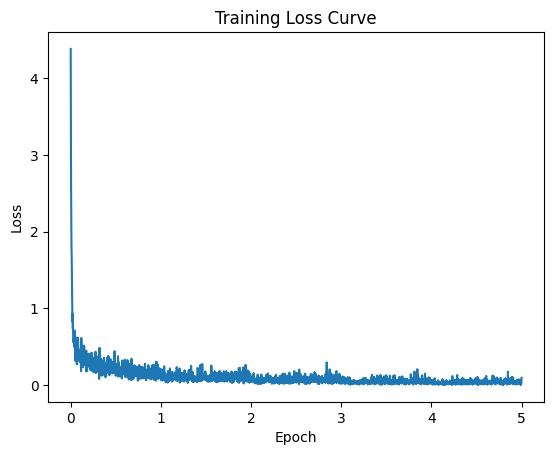

In [116]:

# Include a plot of your train loss curve in the video submission as well as a final accuracy. 
import matplotlib.pyplot as plt
import numpy as np

num_epochs = 5
x_epochs = np.linspace(0, num_epochs, len(losses))

plt.plot(x_epochs, losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.show()
